# Programming Assignment 4

## A. VISAYAS COMMUNICATION DATAFRAME

This filters the board exam dataset to isolate students from the Visayas region who are enrolled in the Communication track, retaining only their names, genders, and specific test scores.

In [1]:
import pandas as pd

df = pd.read_excel('board2.xlsx') #This loads the dataset into a Pandas DataFrame.

df['Average'] = df[['Math', 'GEAS', 'Electronics', 'Communication']].mean(axis=1) #This calculates the average using all four subjects.

#This filters students with Visayas hometown and Communication track, then selects specific columns.
VisComm = df.loc[(df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication'), ['Name', 'Gender', 'Math', 'Electronics', 'Average']]

#This displays the resulting DataFrame and its total number of rows.
print("Number of rows:", VisComm.shape[0])
VisComm

Number of rows: 5


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


## B. VISAYAS FEMALE DATAFRAME

This creates a subset of female students from the Visayas region, displays their specific subject metrics, followed by a secondary filter to highlight those who achieved an average of 60 or higher.

In [2]:
#This filters for Visayas hometown and Female gender, then select specific columns.
VisFemale = df.loc[(df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female'), ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

VisFemale 

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [3]:
VisFemale[VisFemale['Average'] >= 60] #This displays only the rows where the Average is at least 60 without overwriting VisFemale.

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## C. CATEGORY-AVERAGE VISUALIZATION

This computes the mean board exam average across three categorical features (Track, Gender, and Hometown) and visualizes the comparisons using a figure with three bar charts to identify the highest performing groups within the dataset.

In [4]:
import matplotlib.pyplot as plt

#This computes the mean of the average for every category using pivot_table and reset_index to make it regular columns.
track_mean = df.pivot_table(index='Track', values='Average').reset_index()
gender_mean = df.pivot_table(index='Gender', values='Average').reset_index()
hometown_mean = df.pivot_table(index='Hometown', values='Average').reset_index()

#This displays the three summary tables.
display(track_mean)
display(gender_mean)
display(hometown_mean)

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


,Gender,Average
0,Female,66.616667
1,Male,67.183333


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


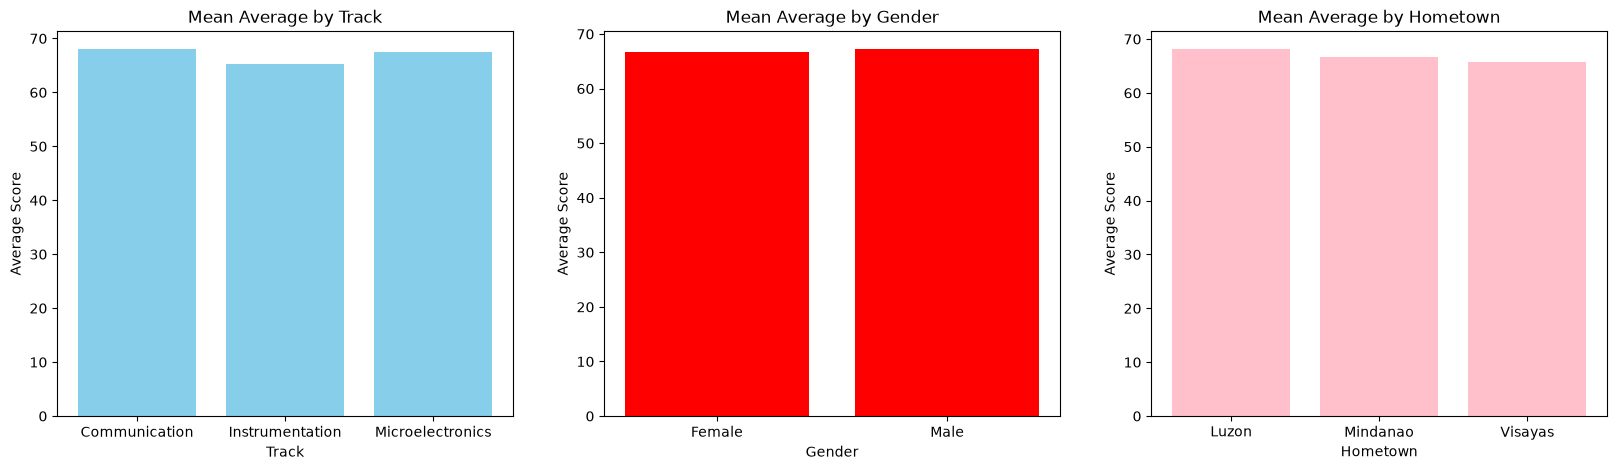

In [5]:
#This creates one figure containing three bar charts
plt.figure(figsize=(20, 5))

#First Chart: Track
plt.subplot(1, 3, 1) 
plt.bar(track_mean['Track'], track_mean['Average'], color='skyblue')
plt.title('Mean Average by Track')
plt.xlabel('Track')
plt.ylabel('Average Score');

#Second Chart: Gender
plt.subplot(1, 3, 2)
plt.bar(gender_mean['Gender'], gender_mean['Average'], color='red')
plt.title('Mean Average by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score');

#Third Chart: Hometown
plt.subplot(1, 3, 3)
plt.bar(hometown_mean['Hometown'], hometown_mean['Average'], color='pink')
plt.title('Mean Average by Hometown')
plt.xlabel('Hometown')
plt.ylabel('Average Score');


Mean Average by Track - Among the tracks observed in this dataset, students in the Communication track have the highest sample mean average.

Mean Average by Gender - Between the genders in this dataset, Male students have the highest sample mean average.

Mean Average by Hometown - Across the hometowns in this dataset, students from Luzon have the highest sample mean average.